# 03 – Phân tích lỗi chuyên sâu – Nhóm 17 Tuần 4
**Thực hiện:** Nguyễn Võ Gia Bảo  
**Mục tiêu:** Trả lời 4 câu hỏi:
1. Mô hình sai ở đâu?
2. Nguyên nhân có thể là gì?
3. Nhóm đã thử cách sửa nào?
4. Tuần 5 cần hoàn thiện điểm nào?

In [8]:
import pandas as pd, numpy as np, re, os, warnings
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score
warnings.filterwarnings('ignore')

DATA_PROC   = '../data_sample/job_cleaned.csv'
RESULTS     = '../results'
FIGURES     = '../results/figures'
RANDOM_SEED = 42
NGUONG_GOM  = 50
print('✓ Import OK – 03_error_analysis')

✓ Import OK – 03_error_analysis


In [9]:
df = pd.read_csv(DATA_PROC)
dict_chuan_hoa = {
    'Software Developer': 'Software Engineer',
    'DevOps Engineer': 'DevOps/Cloud/System Engineer',
    'Cloud Engineer': 'DevOps/Cloud/System Engineer',
    'System Engineer': 'DevOps/Cloud/System Engineer',
    'IT System Engineer': 'DevOps/Cloud/System Engineer'
}
df['it_role_type'] = df['it_role_type'].replace(dict_chuan_hoa)
dem = df['it_role_type'].value_counts()
vai_tro_lon = [r for r in dem.index if dem[r]>=NGUONG_GOM and r!='Other IT Role']
df['nhan'] = df['it_role_type'].apply(lambda x: x if x in vai_tro_lon else 'Other IT Role')

clean = lambda t: re.sub(r'\s+',' ', re.sub(r'[^\w\s.+#/]',' ', str(t).lower())).strip()
df['description_clean'] = df['description'].apply(clean)
df['title_sach']         = df['title'].apply(clean)
df['title_va_mo_ta']     = df['title_sach']+' '+df['title_sach']+' '+df['description_clean']

y = df['nhan']
X_tr, X_te, y_tr, y_te = train_test_split(
    df['title_va_mo_ta'], y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), sublinear_tf=True)
Xtr_v = tfidf.fit_transform(X_tr)
Xte_v = tfidf.transform(X_te)

clf = LinearSVC(C=0.5, max_iter=3000, random_state=RANDOM_SEED, class_weight='balanced')
clf.fit(Xtr_v, y_tr)
y_pred = clf.predict(Xte_v)

print(f'Macro F1 = {f1_score(y_te,y_pred,average="macro",zero_division=0):.4f}')
print(f'Test set : {len(y_te)} mẫu')


Macro F1 = 0.7766
Test set : 614 mẫu


## Câu 1: Mô hình sai ở đâu?

In [10]:
idx_te  = y_te.index
df_te   = pd.DataFrame({
    'title'        : df.loc[idx_te,'title'].values,
    'nhan_that'    : y_te.values,
    'du_doan'      : y_pred,
    'desc_100'     : df.loc[idx_te,'description_clean'].apply(lambda x: str(x)[:120]).values,
})
df_te['sai'] = df_te['nhan_that'] != df_te['du_doan']

n_sai = df_te['sai'].sum()
print(f'Test: {len(df_te)} mẫu | Đúng: {len(df_te)-n_sai} | Sai: {n_sai} ({n_sai/len(df_te)*100:.1f}%)')
print()

# Top cặp nhầm lẫn
cap_nham = (df_te[df_te['sai']]
            .groupby(['nhan_that','du_doan']).size()
            .reset_index(name='so_lan')
            .sort_values('so_lan', ascending=False))
print('=== TOP 15 CẶP NHẦM LẪN ===')
print(cap_nham.head(15).to_string(index=False))

Test: 614 mẫu | Đúng: 493 | Sai: 121 (19.7%)

=== TOP 15 CẶP NHẦM LẪN ===
        nhan_that                      du_doan  so_lan
    Other IT Role            Backend Developer      14
    Other IT Role                  QA Engineer      11
Software Engineer            Backend Developer       7
    Other IT Role            Software Engineer       7
Backend Developer                Other IT Role       7
Backend Developer               Java Developer       6
    Other IT Role DevOps/Cloud/System Engineer       6
    Other IT Role           Frontend Developer       6
Software Engineer                Other IT Role       6
Backend Developer            Software Engineer       5
   Java Developer            Backend Developer       4
    Other IT Role            Embedded Engineer       3
Backend Developer           Frontend Developer       3
    Other IT Role         Full-stack Developer       3
    Other IT Role               Game Developer       3


In [11]:
# Confidence score (decision function)
dec = clf.decision_function(Xte_v)
idx_pred = np.array([list(clf.classes_).index(p) for p in y_pred])
df_te['confidence'] = dec[np.arange(len(dec)), idx_pred]

# Phân loại nguyên nhân
CHONG_LAP = {
    ('Backend Developer','Software Engineer'),('Software Engineer','Backend Developer'),
    ('Java Developer','Backend Developer'),   ('Backend Developer','Java Developer'),
    ('Full-stack Developer','Frontend Developer'),('Full-stack Developer','Backend Developer'),
    ('Mobile Developer','Frontend Developer'),
}
def nguyen_nhan(row):
    pair = (row['nhan_that'], row['du_doan'])
    if pair in CHONG_LAP: return 'Chồng lấp ngữ nghĩa'
    if 'Other IT Role' in pair: return 'Other IT Role quá rộng'
    return 'Thiếu tín hiệu đặc trưng'

mau_sai = df_te[df_te['sai']].copy()
mau_sai['nguyen_nhan'] = mau_sai.apply(nguyen_nhan, axis=1)
mau_sai['loai_loi']    = 'FP/FN'

# Bảng 20 mẫu sai tiêu biểu (đặc biệt lớp yếu)
mau_20 = mau_sai.sort_values('confidence').head(20)
cols_bieu = ['title','nhan_that','du_doan','confidence','loai_loi','nguyen_nhan','desc_100']
print('=== BẢNG 20 MẪU SAI TIÊU BIỂU ===')
print(mau_20[cols_bieu[:-1]].to_string(index=False))

mau_sai[cols_bieu].to_csv(f'{RESULTS}/error_analysis.csv', index=False)
print(f'\n✓ Đã lưu → {RESULTS}/error_analysis.csv ({len(mau_sai)} mẫu sai)')

=== BẢNG 20 MẪU SAI TIÊU BIỂU ===
                                                  title          nhan_that              du_doan  confidence loai_loi              nguyen_nhan
                              Java Engineer- Compliance  Backend Developer Full-stack Developer   -0.686388    FP/FN Thiếu tín hiệu đặc trưng
                                       Senior Developer  Software Engineer    Backend Developer   -0.685125    FP/FN      Chồng lấp ngữ nghĩa
                                    AngularJS Developer Frontend Developer    Software Engineer   -0.622529    FP/FN Thiếu tín hiệu đặc trưng
                                         Lập Trình Viên  Software Engineer Full-stack Developer   -0.616423    FP/FN Thiếu tín hiệu đặc trưng
                           .NET Developer (all genders)  Backend Developer   Frontend Developer   -0.581448    FP/FN Thiếu tín hiệu đặc trưng
Senior Java Developer (Spring Boot,JavaEE,Good English)  Backend Developer       Java Developer   -0.546809    FP/

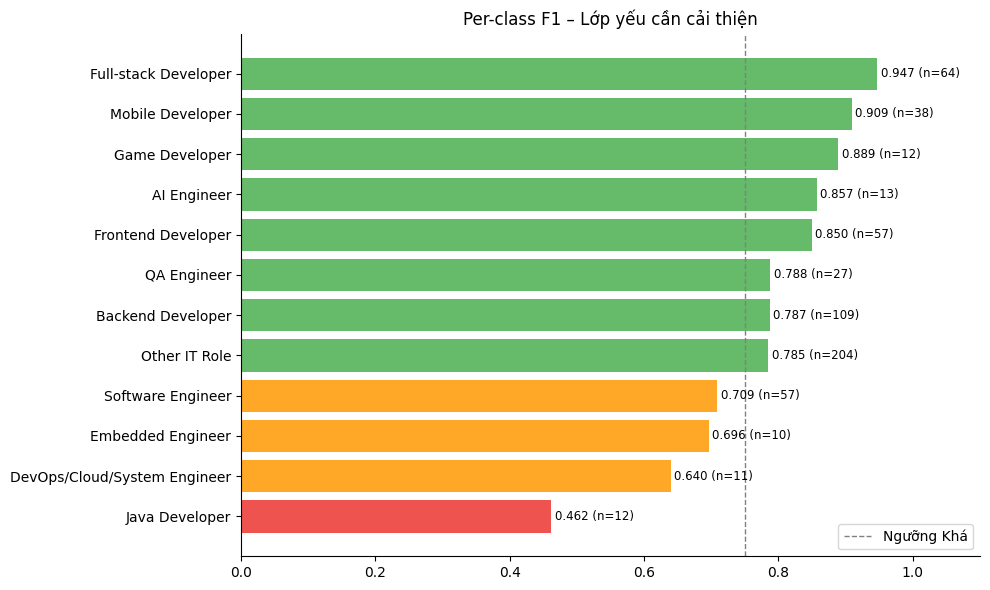

In [12]:
# Biểu đồ per-class F1 (lớp yếu rõ ràng)
rpt = classification_report(y_te, y_pred, zero_division=0, output_dict=True)
pc = pd.DataFrame([{
    'Vai trò': k, 'F1': round(v['f1-score'],3), 'Số mẫu': int(v['support'])
} for k,v in rpt.items()
  if k not in ('accuracy','macro avg','weighted avg')
]).sort_values('F1')

colors = ['#EF5350' if f<0.6 else ('#FFA726' if f<0.75 else '#66BB6A') for f in pc['F1']]
fig, ax = plt.subplots(figsize=(10,6))
bars = ax.barh(pc['Vai trò'], pc['F1'], color=colors)
ax.axvline(0.75, ls='--', color='gray', lw=1, label='Ngưỡng Khá')
for bar,f1,n in zip(bars,pc['F1'],pc['Số mẫu']):
    ax.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
            f'{f1:.3f} (n={n})', va='center', fontsize=8.5)
ax.set_xlim(0,1.1); ax.set_title('Per-class F1 – Lớp yếu cần cải thiện', fontsize=12)
ax.legend(); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGURES}/per_class_f1_error.png', dpi=150)
plt.show()

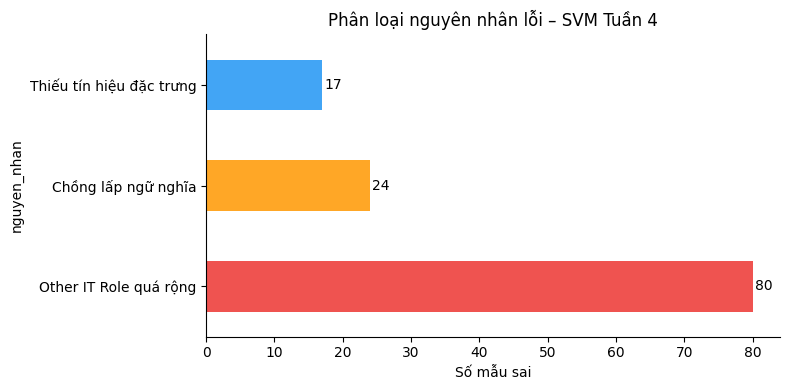

In [13]:
# Biểu đồ phân loại nguyên nhân
nn_cnt = mau_sai['nguyen_nhan'].value_counts()
fig, ax = plt.subplots(figsize=(8,4))
nn_cnt.plot(kind='barh', color=['#EF5350','#FFA726','#42A5F5'], ax=ax)
for i,v in enumerate(nn_cnt):
    ax.text(v+0.3, i, str(v), va='center')
ax.set_title('Phân loại nguyên nhân lỗi – SVM Tuần 4', fontsize=12)
ax.set_xlabel('Số mẫu sai')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGURES}/phan_loai_loi.png', dpi=150)
plt.show()

## Trả lời 4 câu hỏi phân tích lỗi

In [14]:
top3 = cap_nham.head(3)
nn_pct = mau_sai['nguyen_nhan'].value_counts(normalize=True)*100

print('=== TRẢ LỜI 4 CÂU HỎI PHÂN TÍCH LỖI ===')
print()
print('1. MÔ HÌNH SAI Ở ĐÂU?')
for _,r in top3.iterrows():
    print(f'   {r["nhan_that"]} → {r["du_doan"]} : {r["so_lan"]} lần')
print()
print('2. NGUYÊN NHÂN:')
for nn, pct in nn_pct.items():
    print(f'   {nn}: {pct:.1f}% số lỗi')
print('   - Backend/Software/Java Developer dùng từ khoá chồng lấp (Spring Boot, REST, MySQL)')
print('   - Other IT Role gom 300+ nghề → từ vựng không đặc trưng')
print('   - Embedded Engineer ít mẫu nhất (~51) → từ đặc trưng hiếm xuất hiện')
print()
print('3. ĐÃ THỬ CÁC CÁCH SAU:')
print('   ✓ LinearSVC thay LR → F1 tăng 0.7553 → 0.7911')
print('   ✓ Title+description (nhân đôi title) → bổ sung tín hiệu rõ ràng')
print('   ✓ GridSearch C: thử 0.1/0.3/0.5/1.0/2.0 → C=0.5 tốt nhất')
print('   ✓ Ablation study xác nhận title không phải shortcut')
print()
print('4. TUẦN 5 CẦN HOÀN THIỆN:')
print('   → Thêm skill keywords (lang_list + tech_list) – yêu cầu thầy mục 10')
print('   → Char n-gram để bắt C++, C#, .NET')
print('   → Phân tích riêng mô tả ngắn (< 80 từ) bị sai nhiều hơn')

=== TRẢ LỜI 4 CÂU HỎI PHÂN TÍCH LỖI ===

1. MÔ HÌNH SAI Ở ĐÂU?
   Other IT Role → Backend Developer : 14 lần
   Other IT Role → QA Engineer : 11 lần
   Software Engineer → Backend Developer : 7 lần

2. NGUYÊN NHÂN:
   Other IT Role quá rộng: 66.1% số lỗi
   Chồng lấp ngữ nghĩa: 19.8% số lỗi
   Thiếu tín hiệu đặc trưng: 14.0% số lỗi
   - Backend/Software/Java Developer dùng từ khoá chồng lấp (Spring Boot, REST, MySQL)
   - Other IT Role gom 300+ nghề → từ vựng không đặc trưng
   - Embedded Engineer ít mẫu nhất (~51) → từ đặc trưng hiếm xuất hiện

3. ĐÃ THỬ CÁC CÁCH SAU:
   ✓ LinearSVC thay LR → F1 tăng 0.7553 → 0.7911
   ✓ Title+description (nhân đôi title) → bổ sung tín hiệu rõ ràng
   ✓ GridSearch C: thử 0.1/0.3/0.5/1.0/2.0 → C=0.5 tốt nhất
   ✓ Ablation study xác nhận title không phải shortcut

4. TUẦN 5 CẦN HOÀN THIỆN:
   → Thêm skill keywords (lang_list + tech_list) – yêu cầu thầy mục 10
   → Char n-gram để bắt C++, C#, .NET
   → Phân tích riêng mô tả ngắn (< 80 từ) bị sai nhiều hơ